# Fake News Classification — Model Comparison & Final Selection

Compares every model × feature-extraction combination trained across the BoW, TF-IDF,
and Word2Vec notebooks (all logged to the shared `results_logs.jsonl`).

Select final model and evaluates it on the held-out test set.


## 1. Setup

In [1]:
import os
os.chdir('../')
print(os.getcwd())

c:\Users\kriti\Dropbox\PC\Desktop\Ironhack_AI_Engineering\Projects\Project_2\Project-2-Natural-Language-Processing


In [ ]:
import utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from scipy.sparse import hstack

## 2. Load & Compare All Results

Loads every run logged so far (from any of the BoW / TF-IDF / Word2Vec notebooks) and
compares them side by side.

In [10]:
results_df = utils.load_results_from_file()
results_df = results_df.sort_values('f1_score', ascending=False).reset_index(drop=True)
results_df

,timestamp,model_name,method,comments,train_accuracy,test_accuracy,precision,recall,f1_score,confusion_matrix,model_path
0,2026-07-10 12:19:35,Random Forest - BoW,BoW,"Random Forest model with bow(5000 features, ng...",1.000000,0.998623,0.998002,0.99925,0.998626,"[[3981, 8], [3, 3997]]",models\Random_Forest_-_BoW_BoW_2026-07-10_12-1...
1,2026-07-10 12:07:35,Random Forest - TF-IDF,TF-IDF,"Random Forest model with tfidf(5000 features, ...",1.000000,0.998248,0.997504,0.99900,0.998251,"[[3979, 10], [4, 3996]]",models\Random_Forest_-_TF-IDF_TF-IDF_2026-07-1...
2,2026-07-10 12:19:32,Logistic Regression - BoW,BoW,"Baseline LR model with bow(5000 features, ngra...",0.999969,0.996620,0.996749,0.99650,0.996625,"[[3976, 13], [14, 3986]]",models\Logistic_Regression_-_BoW_BoW_2026-07-1...
3,2026-07-10 12:19:33,SVM - BoW,BoW,"SVM model with bow(5000 features, ngram_range=...",0.999969,0.996245,0.995754,0.99675,0.996252,"[[3972, 17], [13, 3987]]",models\SVM_-_BoW_BoW_2026-07-10_12-19-33.pkl
4,2026-07-10 12:07:34,SVM - TF-IDF,TF-IDF,"SVM model with tfidf(5000 features, ngram_rang...",0.999969,0.995744,0.995255,0.99625,0.995752,"[[3970, 19], [15, 3985]]",models\SVM_-_TF-IDF_TF-IDF_2026-07-10_12-07-34...
5,2026-07-10 12:07:33,Logistic Regression - TF-IDF,TF-IDF,"Baseline LR model with tfidf(5000 features, ng...",0.996839,0.991864,0.990771,0.99300,0.991884,"[[3952, 37], [28, 3972]]",models\Logistic_Regression_-_TF-IDF_TF-IDF_202...
6,2026-07-10 12:27:20,SVM - Word2Vec,Word2Vec,"SVM model with word2vec(100 dims, sg=1)",0.984227,0.983227,0.983976,0.98250,0.983237,"[[3925, 64], [70, 3930]]",models\SVM_-_Word2Vec_Word2Vec_2026-07-10_12-2...
7,2026-07-10 12:27:17,Logistic Regression - Word2Vec,Word2Vec,"Baseline LR model with word2vec(100 dims, sg=1)",0.978625,0.977845,0.978713,0.97700,0.977856,"[[3904, 85], [92, 3908]]",models\Logistic_Regression_-_Word2Vec_Word2Vec...
8,2026-07-10 12:19:33,Naive Bayes - BoW,BoW,"Naive Bayes model with bow(5000 features, ngra...",0.964542,0.960446,0.957072,0.96425,0.960648,"[[3816, 173], [143, 3857]]",models\Naive_Bayes_-_BoW_BoW_2026-07-10_12-19-...
9,2026-07-10 12:27:24,Random Forest - Word2Vec,Word2Vec,"Random Forest model with word2vec(100 dims, sg=1)",1.000000,0.960946,0.970648,0.95075,0.960596,"[[3874, 115], [197, 3803]]",models\Random_Forest_-_Word2Vec_Word2Vec_2026-...


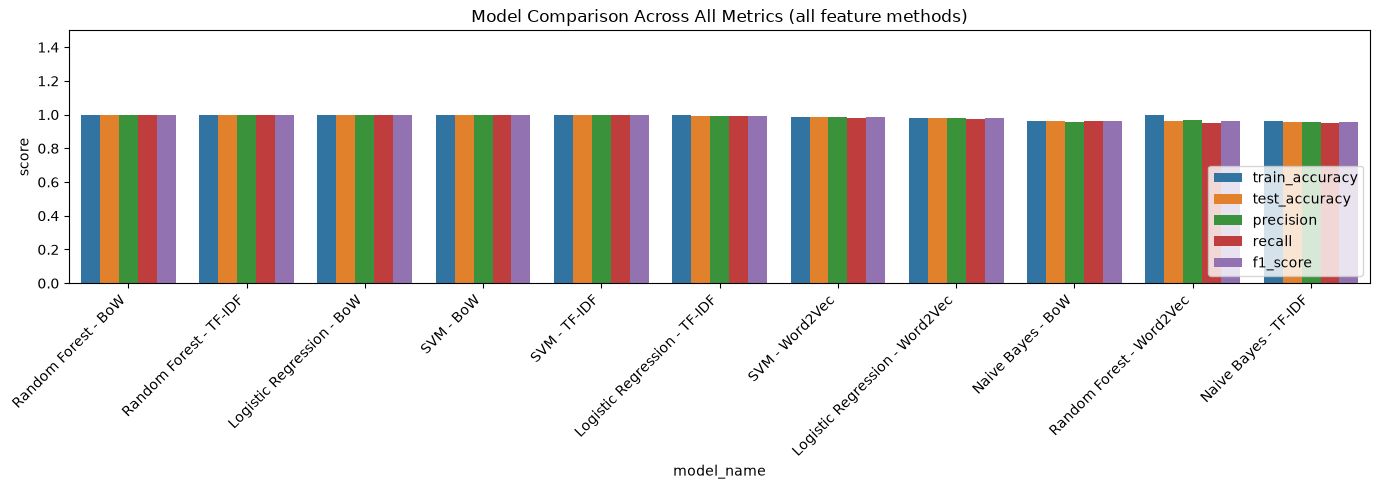

In [11]:
# --- Bar plot: all metrics, all model x method combinations ---
metrics_to_plot = ['train_accuracy', 'test_accuracy', 'precision', 'recall', 'f1_score']
plot_df = results_df.melt(id_vars='model_name', value_vars=metrics_to_plot,
                           var_name='metric', value_name='score')

plt.figure(figsize=(14, 5))
sns.barplot(data=plot_df, x='model_name', y='score', hue='metric')
plt.title('Model Comparison Across All Metrics (all feature methods)')
plt.ylim(0, 1.5)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


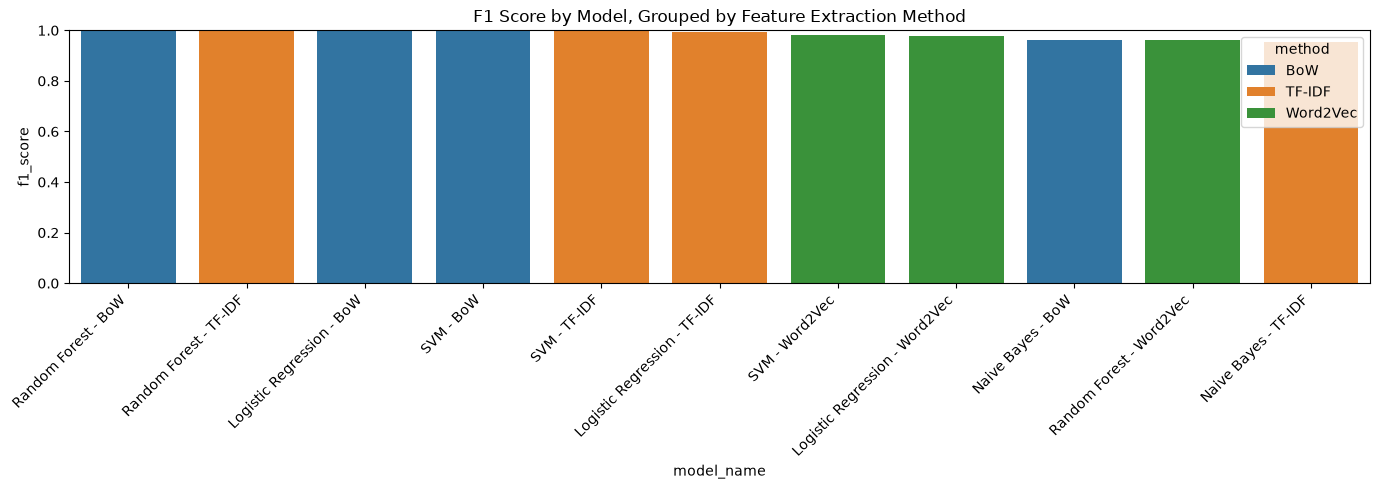

In [12]:
# --- F1 score, grouped by feature-extraction method ---
plt.figure(figsize=(14, 5))
sns.barplot(data=results_df, x='model_name', y='f1_score', hue='method')
plt.title('F1 Score by Model, Grouped by Feature Extraction Method')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Comments

- Based on `results_df`, **Random Forest with BoW** is the best-performing model overall, with an F1 score of **0.9986**.
- Looking at the F1 score plot grouped by feature-extraction method, **BoW** consistently outperforms the other extraction methods.
- The baseline **Logistic Regression with BoW** is the third best-performing model, which is a strong result for such a simple model.
- **Word2Vec** performs reasonably well in absolute terms, but is the weakest of the three feature-extraction methods compared to BoW and TF-IDF.

### Final Selection

- We will move forward with **Logistic Regression (BoW)**.
- **Logistic Regression** is chosen because it's the baseline model and already performs very well, at a fraction of the training cost.
- **Random Forest** is the best-performing model overall, but takes noticeably longer to train than the other models.
- Selecting these two models lets us compare a fast, simple baseline against the top performer when predicting on the test set.

## 3. Final Model Selection

Review the table/plots above, then set `SELECTED_INDEX` below to the `results_df` row
you want to use as the final model. (Default: the top row, i.e. highest F1 score —
change this to whichever row you decide on.)

In [51]:
# Logistic Regression

selected_row_lr = results_df.iloc[0]
print("Selected model:", selected_row_lr['model_name'])
print("Feature method:", selected_row_lr['method'])
print("Comments:", selected_row_lr['comments'])
print(f"Test Accuracy: {selected_row_lr['test_accuracy']:.4f}")
print(f"F1 Score:      {selected_row_lr['f1_score']:.4f}")
print("Model file:", selected_row_lr['model_path'])

Selected model: Random Forest - BoW
Feature method: BoW
Comments: Random Forest model with bow(5000 features, ngram_range=(1,2))
Test Accuracy: 0.9986
F1 Score:      0.9986
Model file: models\Random_Forest_-_BoW_BoW_2026-07-10_12-19-35.pkl


In [52]:
final_model_lr = utils.load_model_from_file(selected_row_lr['model_path'])
final_method_lr = selected_row_lr['method']   # 'BoW', 'TF-IDF', or 'Word2Vec'
final_model_lr

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## 4. Rebuild Matching Test Features

The saved model expects features in the same shape/space it was trained on. Since the
fitted vectorizers themselves weren't persisted (only the trained models were), this
section **recreates the same train/test split and re-fits the matching vectorizer**
on the cached cleaned text — using the same parameters as the original pipeline
notebooks (5000 features, ngram_range=(1,2) for BoW/TF-IDF; 100-dim Word2Vec, sg=1).

> **Tip for future runs:** to skip this recomputation step entirely, save the fitted
> vectorizer/Word2Vec model in each pipeline notebook too, e.g.:
> `utils.save_model_to_file(tfidf_vectorizer, "tfidf_vectorizer", "title", timestamp)`
> — `save_model_to_file`/`load_model_from_file` are generic pickle helpers, so they
> work for vectorizers just as well as for models.


In [40]:
TEXT_COLUMNS = ['title', 'text']

In [41]:
# Load real test data
test_data = pd.read_csv('dataset/validation_data.csv').drop(columns=['subject', 'date'])
X_TEST = test_data.drop(columns='label')
y_TEST = test_data['label']

# Preprocess text columns and keep only preprocessed columns
X_TEST_CLEAN = utils.preprocess_text_columns(X_TEST, TEXT_COLUMNS)[[f'{c}_clean' for c in TEXT_COLUMNS]]
X_TEST_CLEAN.columns = TEXT_COLUMNS
X_TEST_CLEAN.head()

,title,text
0,uk may receiving regular update london tube st...,london reuters british prime minister theresa ...
1,uk transport police leading investigation lond...,london reuters british counter terrorism polic...
2,pacific nation crack north korean ship fiji pr...,wellington reuters south pacific island nation...
3,three suspected al qaeda militant killed yemen...,aden yemen reuters three suspected al qaeda mi...
4,chinese academic prod beijing consider north k...,beijing reuters chinese academic publicly broa...


In [42]:
raw_data = pd.read_csv('dataset/data.csv').drop(columns=['subject', 'date'])
X = raw_data.drop(columns='label')
y = raw_data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Reload cached cleaned text (must already exist from a pipeline notebook run) ---
X_train_clean = pd.read_csv('X_train_clean.csv', index_col=0).fillna('')
#X_test_clean = pd.read_csv('X_test_clean.csv', index_col=0).fillna('')


In [43]:
def build_bow_features(vectorizer_cls, X_train_clean, X_test_clean, text_columns):
    train_feats, test_feats = [], []
    for col in text_columns:
        vectorizer = vectorizer_cls(max_features=5000, ngram_range=(1, 2))
        train_feats.append(vectorizer.fit_transform(X_train_clean[col]))
        test_feats.append(vectorizer.transform(X_test_clean[col]))
    return hstack(train_feats), hstack(test_feats)

X_train_final, X_TEST_FINAL = build_bow_features(CountVectorizer, X_train_clean, X_TEST_CLEAN, TEXT_COLUMNS)
print("Test feature matrix:", X_TEST_FINAL.shape)

Test feature matrix: (4956, 10000)


## 5. Predict on Test Data

In [44]:
y_test_pred_lr = final_model_lr.predict(X_TEST_FINAL)

print("Predictions of Logistic Regression on test set (first 20):")
print(y_test_pred_lr[:20])


Predictions of Logistic Regression on test set (first 20):
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [47]:
test_data_preds = pd.read_csv('dataset/validation_data.csv')
test_data_preds['label'] = y_test_pred_lr
test_data_preds

,label,title,text,subject,date
0,1,UK's May 'receiving regular updates' on London...,LONDON (Reuters) - British Prime Minister Ther...,worldnews,"September 15, 2017"
1,1,UK transport police leading investigation of L...,LONDON (Reuters) - British counter-terrorism p...,worldnews,"September 15, 2017"
2,1,Pacific nations crack down on North Korean shi...,WELLINGTON (Reuters) - South Pacific island na...,worldnews,"September 15, 2017"
3,1,Three suspected al Qaeda militants killed in Y...,"ADEN, Yemen (Reuters) - Three suspected al Qae...",worldnews,"September 15, 2017"
4,1,Chinese academics prod Beijing to consider Nor...,BEIJING (Reuters) - Chinese academics are publ...,worldnews,"September 15, 2017"
...,...,...,...,...,...
4951,0,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
4952,0,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
4953,0,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
4954,0,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [ ]:
#test_data_preds.to_csv('dataset/validation_data_preds.csv')